In [25]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

df = pd.read_excel(
    r"C:/Users/user/OneDrive/Documents/default of credit card clients.xlsx",
    header=1
)

df.info()
df.describe()

df.rename(columns={
    "default payment next month":"Default_Payment"
}, inplace=True)

df.head()
df.isnull().sum()
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.shape
df.dtypes
df.columns
df.rename(columns={'default payment next month': 'Default_Payment'}, inplace=True)
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'Default_Payment'],
      dtype='object')

In [29]:
#Convert Gender
df['SEX'] = df['SEX'].replace({
    1: 'Male',
    2: 'Female'
})

df['SEX'].value_counts()

#Convert Education
df['EDUCATION'] = df['EDUCATION'].replace({
    0: 'Unknown',
    1: 'Graduate School',
    2: 'University',
    3: 'High School',
    4: 'Others',
    5: 'Unknown',
    6: 'Unknown'
})

df['EDUCATION'].value_counts()

#Convert Marriage
df['MARRIAGE'] = df['MARRIAGE'].replace({
    0: 'Unknown',
    1: 'Married',
    2: 'Single',
    3: 'Others'
})

df['MARRIAGE'].value_counts()

#Convert Payment
df['Default_Payment'] = df['Default_Payment'].replace({
    0: 'No',
    1: 'Yes'
})

df['Default_Payment'].value_counts()


Default_Payment
No     23364
Yes     6636
Name: count, dtype: int64

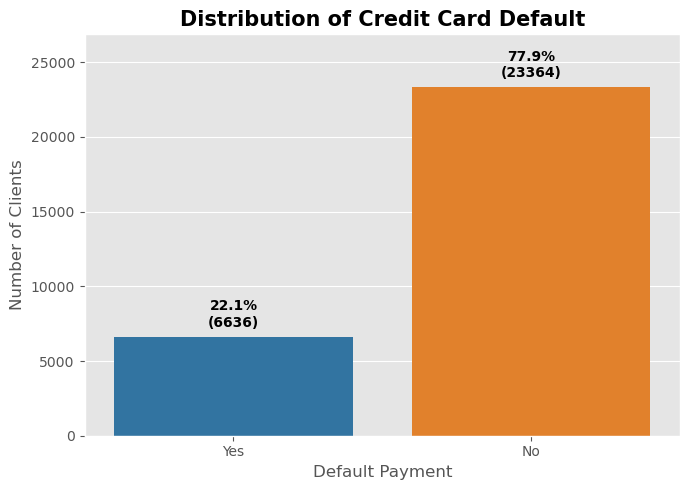

In [32]:
#Visualization 1
plt.figure(figsize=(7,5))

colors = ['#1f77b4', '#ff7f0e']   # Blue and Orange

ax = sns.countplot(
    x='Default_Payment',
    hue='Default_Payment',
    data=df,
    palette=colors,
    legend=False
)

plt.title('Distribution of Credit Card Default', fontsize=15, fontweight='bold')
plt.xlabel('Default Payment', fontsize=12)
plt.ylabel('Number of Clients', fontsize=12)

# Add some space above the tallest bar
plt.ylim(0, max(df['Default_Payment'].value_counts()) * 1.15)

total = len(df)

for p in ax.patches:
    percentage = 100 * p.get_height() / total
    ax.annotate(
        f'{percentage:.1f}%\n({int(p.get_height())})',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom',
        xytext=(0,5),               # Move text slightly above the bar
        textcoords='offset points',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

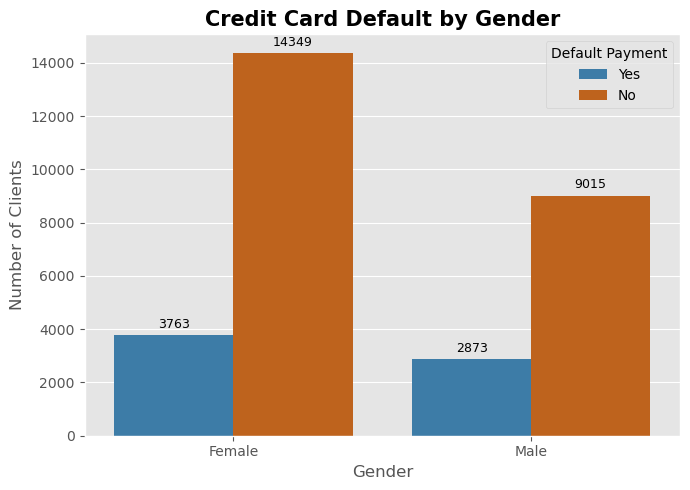

In [34]:
#Visualization 2
plt.figure(figsize=(7,5))

colors = ['#2C7FB8', '#D95F02']   # Blue and Orange

ax = sns.countplot(
    x='SEX',
    hue='Default_Payment',
    data=df,
    palette=colors
)

plt.title('Credit Card Default by Gender', fontsize=15, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Number of Clients', fontsize=12)

# Add values on top of each bar
for container in ax.containers:
    ax.bar_label(container, fontsize=9, padding=3)

plt.legend(
    title='Default Payment',
    loc='upper right',
    frameon=True
)

plt.tight_layout()
plt.show()

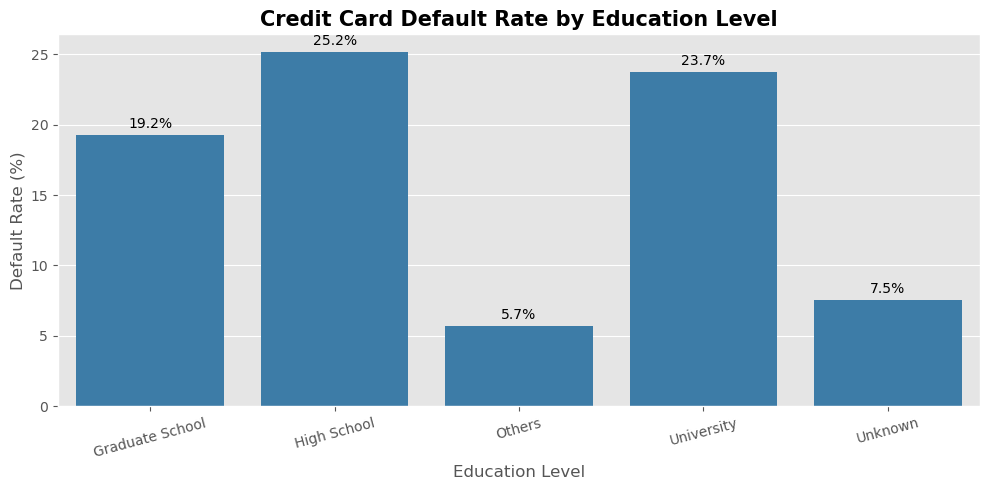

In [35]:
# Visualization 3
# Calculate default rate by education
education_default = (
    df.groupby('EDUCATION')['Default_Payment']
      .value_counts(normalize=True)
      .rename('Percentage')
      .mul(100)
      .reset_index()
)

# Keep only customers who defaulted
education_default = education_default[
    education_default['Default_Payment'] == 'Yes'
]

plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=education_default,
    x='EDUCATION',
    y='Percentage',
    color='#2C7FB8'
)

plt.title('Credit Card Default Rate by Education Level',
          fontsize=15,
          fontweight='bold')

plt.xlabel('Education Level', fontsize=12)
plt.ylabel('Default Rate (%)', fontsize=12)

plt.xticks(rotation=15)

# Display percentages
for container in ax.containers:
    ax.bar_label(container,
                 fmt='%.1f%%',
                 fontsize=10,
                 padding=3)

plt.tight_layout()
plt.show()

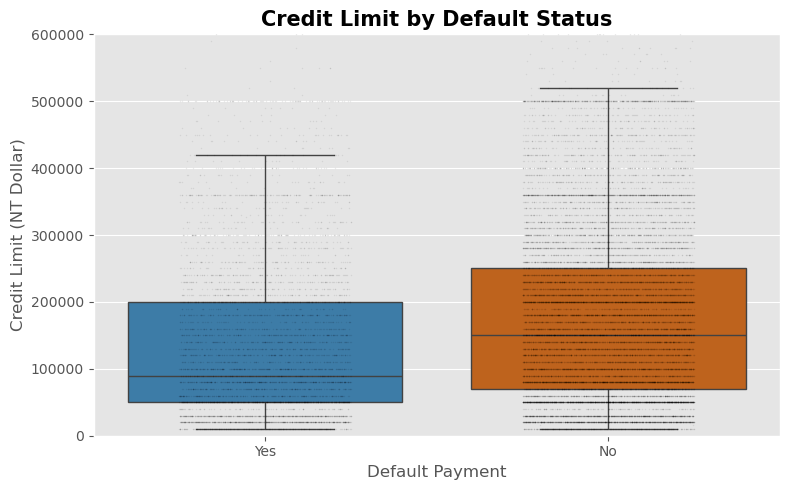

In [42]:
# Visualization 4
plt.figure(figsize=(8,5))

ax = sns.boxplot(
    x='Default_Payment',
    y='LIMIT_BAL',
    hue='Default_Payment',
    data=df,
    palette={
        'Yes':'#2C7FB8',
        'No':'#D95F02'
    },
    legend=False,
    showfliers=False
)

sns.stripplot(
    x='Default_Payment',
    y='LIMIT_BAL',
    data=df,
    color='black',
    alpha=0.08,
    size=1,
    jitter=0.25
)

plt.title('Credit Limit by Default Status',
          fontsize=15,
          fontweight='bold')

plt.xlabel('Default Payment', fontsize=12)
plt.ylabel('Credit Limit (NT Dollar)', fontsize=12)

plt.ylim(0, 600000)
plt.tight_layout()
plt.show()

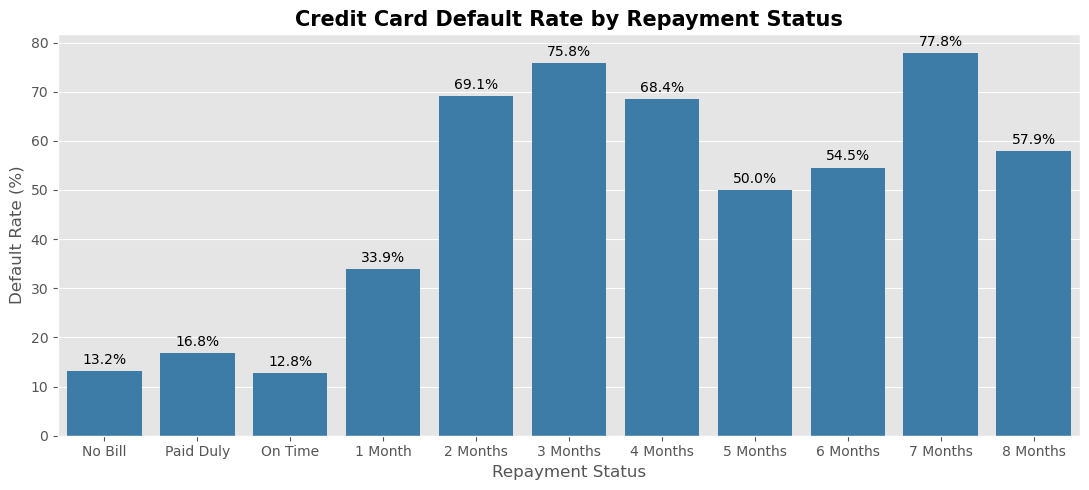

In [53]:
# Visualization 5
# Calculate default rate by repayment status
pay_default = (
    df.groupby('PAY_0')['Default_Payment']
      .value_counts(normalize=True)
      .rename('Percentage')
      .mul(100)
      .reset_index()
)

# Keep only customers who defaulted
pay_default = pay_default[
    pay_default['Default_Payment'] == 'Yes'
]

# Convert repayment status into readable labels
pay_labels = {
    -2: 'No Bill',
    -1: 'Paid Duly',
     0: 'On Time',
     1: '1 Month',
     2: '2 Months',
     3: '3 Months',
     4: '4 Months',
     5: '5 Months',
     6: '6 Months',
     7: '7 Months',
     8: '8 Months'
}

pay_default['Repayment_Status'] = pay_default['PAY_0'].map(pay_labels)

# Preserve the logical order
order = [
    'No Bill',
    'Paid Duly',
    'On Time',
    '1 Month',
    '2 Months',
    '3 Months',
    '4 Months',
    '5 Months',
    '6 Months',
    '7 Months',
    '8 Months'
]

plt.figure(figsize=(11,5))

ax = sns.barplot(
    data=pay_default,
    x='Repayment_Status',
    y='Percentage',
    order=order,
    color='#2C7FB8'
)

plt.title(
    'Credit Card Default Rate by Repayment Status',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Repayment Status', fontsize=12)
plt.ylabel('Default Rate (%)', fontsize=12)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        fontsize=10,
        padding=3
    )

plt.tight_layout()
plt.show()

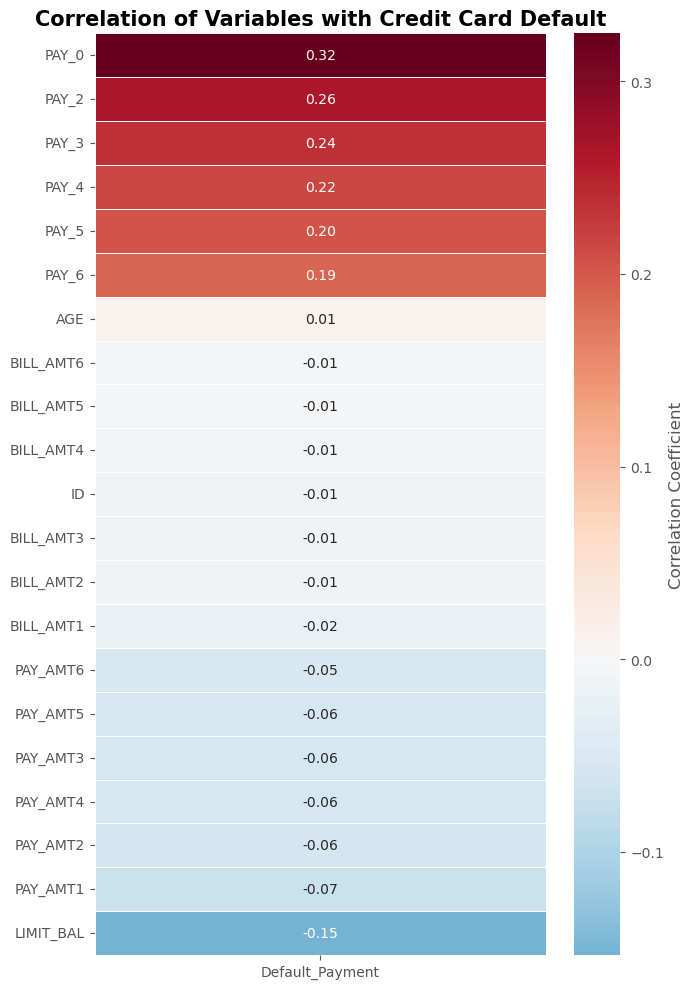

In [55]:
# Visualization 6 - Correlation Analysis
corr = df.copy()

# Convert target variable back to numeric
corr['Default_Payment'] = corr['Default_Payment'].map({
    'No': 0,
    'Yes': 1
})

# Calculate correlation
correlation = (
    corr.corr(numeric_only=True)[['Default_Payment']]
        .drop(index='Default_Payment')
        .sort_values(by='Default_Payment', ascending=False)
)

# Sort from strongest positive to strongest negative
correlation = correlation.sort_values(
    by='Default_Payment',
    ascending=False
)

plt.figure(figsize=(7,10))

sns.heatmap(
    correlation,
    annot=True,
    cmap='RdBu_r',
    center=0,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={'label': 'Correlation Coefficient'}
)

plt.title(
    'Correlation of Variables with Credit Card Default',
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [56]:
from scipy.stats import chi2_contingency

gender_table = pd.crosstab(df['SEX'], df['Default_Payment'])

chi2, p, dof, expected = chi2_contingency(gender_table)

print("Gender vs Default")
print("------------------------")
print(f"Chi-square Statistic : {chi2:.3f}")
print(f"P-value              : {p:.5f}")
print(f"Degrees of Freedom   : {dof}")

if p < 0.05:
    print("\nDecision: Reject H0")
    print("There is a statistically significant association between Gender and Credit Card Default.")
else:
    print("\nDecision: Fail to Reject H0")
    print("There is no statistically significant association between Gender and Credit Card Default.")

Gender vs Default
------------------------
Chi-square Statistic : 47.709
P-value              : 0.00000
Degrees of Freedom   : 1

Decision: Reject H0
There is a statistically significant association between Gender and Credit Card Default.


In [57]:
education_table = pd.crosstab(df['EDUCATION'], df['Default_Payment'])

chi2, p, dof, expected = chi2_contingency(education_table)

print("Education vs Default")
print("------------------------")
print(f"Chi-square Statistic : {chi2:.3f}")
print(f"P-value              : {p:.5f}")
print(f"Degrees of Freedom   : {dof}")

if p < 0.05:
    print("\nDecision: Reject H0")
    print("There is a statistically significant association between Education Level and Credit Card Default.")
else:
    print("\nDecision: Fail to Reject H0")
    print("There is no statistically significant association between Education Level and Credit Card Default.")

Education vs Default
------------------------
Chi-square Statistic : 160.589
P-value              : 0.00000
Degrees of Freedom   : 4

Decision: Reject H0
There is a statistically significant association between Education Level and Credit Card Default.


In [58]:
marriage_table = pd.crosstab(df['MARRIAGE'], df['Default_Payment'])

chi2, p, dof, expected = chi2_contingency(marriage_table)

print("Marriage vs Default")
print("------------------------")
print(f"Chi-square Statistic : {chi2:.3f}")
print(f"P-value              : {p:.5f}")
print(f"Degrees of Freedom   : {dof}")

if p < 0.05:
    print("\nDecision: Reject H0")
    print("There is a statistically significant association between Marital Status and Credit Card Default.")
else:
    print("\nDecision: Fail to Reject H0")
    print("There is no statistically significant association between Marital Status and Credit Card Default.")

Marriage vs Default
------------------------
Chi-square Statistic : 35.662
P-value              : 0.00000
Degrees of Freedom   : 3

Decision: Reject H0
There is a statistically significant association between Marital Status and Credit Card Default.


In [59]:
from scipy.stats import ttest_ind

default = df[df['Default_Payment'] == 'Yes']['LIMIT_BAL']
non_default = df[df['Default_Payment'] == 'No']['LIMIT_BAL']

t_stat, p = ttest_ind(default, non_default)

print("Credit Limit vs Default")
print("------------------------")
print(f"T-statistic : {t_stat:.3f}")
print(f"P-value     : {p:.5f}")

if p < 0.05:
    print("\nDecision: Reject H0")
    print("There is a statistically significant difference in credit limits between customers who defaulted and customers who did not.")
else:
    print("\nDecision: Fail to Reject H0")
    print("There is no statistically significant difference in credit limits between customers who defaulted and customers who did not.")

Credit Limit vs Default
------------------------
T-statistic : -26.909
P-value     : 0.00000

Decision: Reject H0
There is a statistically significant difference in credit limits between customers who defaulted and customers who did not.
